# fMRI to image occlusion pathfinder

The goal of this notebook is to show if we can "see something" interpretable doing targeted manipulation of the fMRI data and inspecting reconstructed images. For example, the assumption would be that in a scene primarily showing a building, fMRI decoding would be more sensitive in the 'places'-area than in the 'faces'-area. If this is successful, the experiment can be systematically extended as part of the thesis.

We require at least the following components to have be able to interpret the result:
1. The baseline image reconstruction has to be interpretable and at least roughly true to the ground truth stimulus. E.g. for a stimulus showing a face, the reconstruction should also show a face, for a stimulus showing a cat the reconstruction should also show a cat etc.
2. The stimulus has to belong to a category that is somewhat represented in the functionally located areas of the subjects brain (faces, bodies, places)
3. A test and control manipulated fMRI sample. If the reconstruction changes interpretably for a manipulation of the expected functional region it also has to be checked how it responds to manipulations in different regions.

# Review of stimulus examples

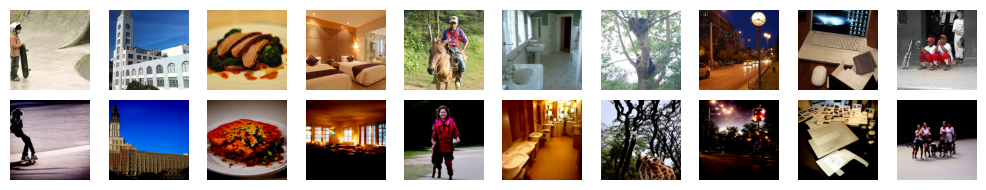

In [9]:
# load and display first 10 images of raw stimuli
import matplotlib.pyplot as plt
import PIL.Image as Image
import os

stimuli_dir = "../../sample_data/images"

img_ids = [62, 67, 82, 84, 90, 124, 163, 177, 193, 223]
stimuli_imgs = []

for i in img_ids:
    img_path = os.path.join(stimuli_dir, f"{i}.png")
    stimuli_imgs.append(Image.open(img_path))

recon_dir = "../../sample_data/images_recon"

recon_imgs = []

for i in img_ids:
    recon_path = os.path.join(recon_dir, f"{i}.png")
    recon_imgs.append(Image.open(recon_path))

# display the first 10 images of raw stimuli and their reconstructions in two rows
# top stimuli, bottom reconstructions
plt.figure(figsize=(10, 2))
for i in range(len(stimuli_imgs)):
    plt.subplot(2, 10, i + 1)
    plt.imshow(stimuli_imgs[i])
    plt.axis("off")
    plt.subplot(2, 10, i + 11)
    plt.imshow(recon_imgs[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

The first five images look somewhat interpretable semantically, so we chose them for our initial experiments.
The next step is to load the associated fMRI responses and the subject-specific floc masks.

In [2]:
import torch

fmri_zscores = torch.load('../../sample_data/fmri_zscores.pt')

zscores_mean = fmri_zscores.mean(dim=1) # neuroflow uses mean across trials for reconstruction

print(zscores_mean.shape)

torch.Size([50, 15724])


In [3]:
# The data has to be transformed back to voxel space before we can filter for any functional region
from fmri_utils import transform_to_voxel_space
nsd_general_mask_path = "../../sample_data/roi/nsdgeneral.nii.gz"

nib_imgs = []
for zscore in zscores_mean:
    voxel_space_img = transform_to_voxel_space(zscore, nsd_general_mask_path)
    nib_imgs.append(voxel_space_img)

In [4]:
# Now we can extract and manipulate individual regions from the fLoc experiments
from fmri_utils import get_roi_names

ROI = "floc-places"

places_id_to_name, places_name_to_id = get_roi_names(ROI, "../../sample_data/label")

places_id_to_name

{0: 'Unknown', 1: 'OPA', 2: 'PPA', 3: 'RSC'}

# Layout of the transformations
I believe a good first start is to define

1. a set of transformations to be applied to the fMRI region of interest (ROI)
2. a set of regions of interest on to which the transformations are applied

## 1. Transformations

- the naive and most simple one is to just set all values in the ROI to 0, indicating no relationship to the given stimulus - this can be easily implemented, of course
- random noise - randomly sample the ROI from a normal distribution according to its mean and std.
- more complex transformations - take into account typical activation patters

## 2. Regions of interest

I think it makes sense to start with the basic areas
- Fusiform body area (FBA), combining NSD FBA-1 and FBA-2
- Fusiform face ares (FFA), combining NSD FBA-1 and FBA-1
- Parahippocampal place area (PPA)

This will lead an experiment structure in the form of a 2d grid: transforms x ROI, in this case 2 x 3 = 6

In [12]:
import nibabel as nib
import numpy as np

# The next step is to optain the required masks for the regions of interest
def get_roi_mask(roi_ids, mask_file):
    mask_img = nib.load(mask_file)
    mask_data = mask_img.get_fdata()
    roi_mask = np.isin(mask_data, roi_ids)

    return roi_mask

fba_mask = get_roi_mask(roi_ids=[2, 3], mask_file='../../sample_data/roi/floc-bodies.nii.gz')
ffa_mask = get_roi_mask(roi_ids=[2, 3], mask_file='../../sample_data/roi/floc-faces.nii.gz')
ppa_mask = get_roi_mask(roi_ids=[2], mask_file='../../sample_data/roi/floc-places.nii.gz')

masks = {
    'fba': fba_mask,
    'ffa': ffa_mask,
    'ppa': ppa_mask
}

In [13]:
# first 5 images are of interest

nsdgeneral_mask = get_roi_mask(roi_ids=[1], mask_file='../../sample_data/roi/nsdgeneral.nii.gz')
sample_data = [sample.get_fdata() for sample in nib_imgs[:5]]
rng = np.random.default_rng(99)

# define transforms

def random_noise_mask(mask, sample, rng=np.random.default_rng(99)):
    masked = sample[mask]
    masked_mean = masked.mean()
    masked_std = masked.std()
    masked_noise = rng.normal(loc=masked_mean, scale=masked_std, size=masked.shape)
    sample_noised = sample.copy()
    sample_noised[mask] = masked_noise
    return sample_noised

def zero_mask(mask, sample, rng):
    masked = sample[mask]
    masked_zero = np.zeros_like(masked)
    sample_zeroed = sample.copy()
    sample_zeroed[mask] = masked_zero
    return sample_zeroed

transforms = {
    'random_noise': random_noise_mask,
    'zero': zero_mask,
}

# transform and save samples for each combination of transform and mask
for transform_name, transform_func in transforms.items():
    for mask_name, mask in masks.items():
        samples_transformed = []

        for sample in sample_data:
            sample_transformed = transform_func(mask, sample, rng=rng)
            sample_transformed = sample_transformed[nsdgeneral_mask]
            samples_transformed.append(sample_transformed)

        # transform to torch tensor and add trial dimension
        samples_transformed = torch.from_numpy(np.array(samples_transformed)).unsqueeze(1)
        torch.save(samples_transformed, f'fmri_data/samples_{transform_name}_{mask_name}.pt')

# Run inference on the manipulated samples

This requires the definition of config files for script/full_inference.py

# Analyze results

Load reconstructed images

ROI: fba, Transform: random_noise


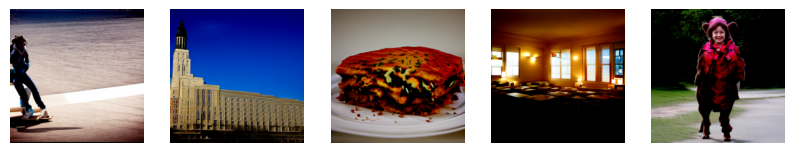

ROI: fba, Transform: zero


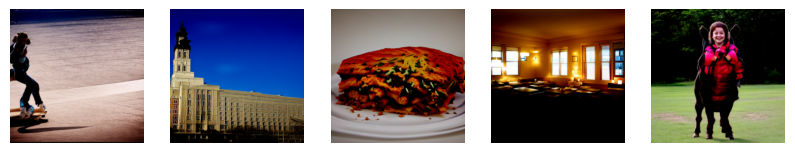

ROI: ffa, Transform: random_noise


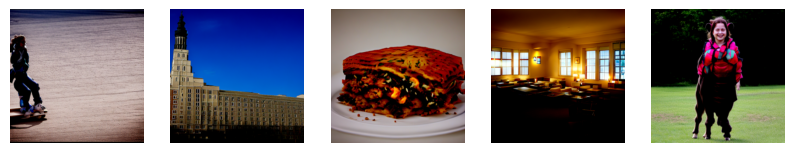

ROI: ffa, Transform: zero


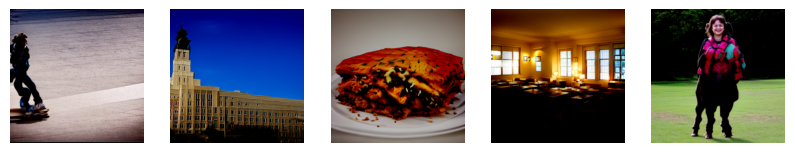

ROI: ppa, Transform: random_noise


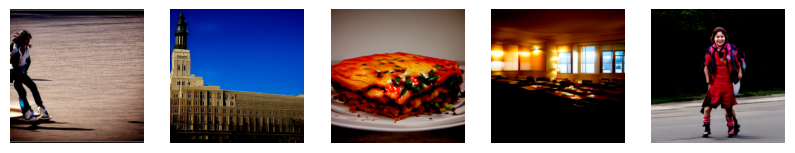

ROI: ppa, Transform: zero


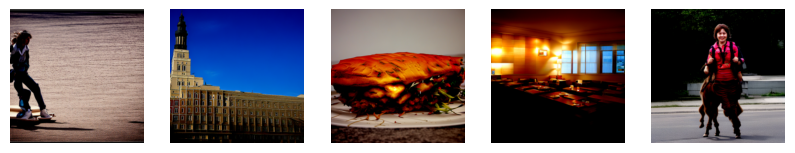

In [16]:
for roi in masks.keys():
    for transform in transforms.keys():
        recon_imgs = torch.load(f'/u/fdammeier/artifacts/fmri_occlusion_{roi}_{transform}/reconstructed_images.pt')

        recon_imgs.clamp_(0, 1)

        # shape = N x C x H x W
        # plot images
        print(f"ROI: {roi}, Transform: {transform}")
        plt.figure(figsize=(10, 2))
        for i in range(recon_imgs.shape[0]):
            img = recon_imgs[i].squeeze().permute(1, 2, 0).numpy()  # convert to H x W x C
            plt.subplot(1, recon_imgs.shape[0], i + 1)
            plt.imshow(img)
            plt.axis('off')
        plt.show()